# Elo updates

Just some basic tests implementing `Elo` ratings and probabilities

In [1]:
import numpy as np
import math

In [2]:
sig = lambda x : 1/(1 + np.exp(-x)); # standard sigmoid
elo_sig = lambda x : 1/(1 + 10**(-x/400)); # Elo-scaled sigmoid

def elo_P(rA,rB): return elo_sig(rA-rB) # P(A wins)

# accounts for the different K-values used by PS
def elo_K_poke(rA,sA):
    assert rA >= 1000;
    if (1000 <= rA < 1100) :
        if (sA == 1) : return 50 + 30*(1100-rA)/100
        else : return 50 - 30*(1100-rA)/100
    if (1100 <= rA < 1300) :
        return 50
    if (rA >= 1300) :
        return 40

In [3]:
# basic test
rA=1103
rB=1020

eA = elo_P(rA,rB)
eB = elo_P(rB,rA)

# scores = {0,1/2,1} for {Win, Draw, Lose}
sA = 1.0
sB = 0.0

def elo_new(rA,rB,sA):
    eA = elo_P(rA,rB)
    elo_comp = rA + elo_K_poke(rA,sA)*(sA-eA);
    return max(1000, int(np.round(elo_comp)))
    
print("rA_old =", rA, "  rA_new =", elo_new(rA,rB,sA))
print("rB_old =", rB, "  rB_new =", elo_new(rB,rA,sB))

rA_old = 1103   rA_new = 1122
rB_old = 1020   rB_new = 1010


# Simulating GXE

In [4]:
from dataclasses import dataclass
import numpy.random as rnd
import pandas as pd

# The minimum stats needed to compute Glicko-1 score
@dataclass
class Player:
    id: int
    r: int
    d: int

# "average" player, using seed `r` and `d`
Plr_seed = Player(id=-1, r=1500, d=350) 

GLICKO_C = 3 * np.log(10)**2 / (400 * np.pi)**2

# P(A wins vs B)
def glicko_P(rA,dA,rB,dB):     
    return 1 / (1 + 10**( -(rA-rB) / (400 * np.sqrt(1 + GLICKO_C*(dA**2 + dB**2))) )) 

In [5]:
# randomly generate N players with various Glicko-1 ratings.
def GXE_simulate(N=250):
    # NOTE: the distributions for picking r and D were based only on trying to approximate
    # X-Act's data; there is no evidence that real player scores will look like this
    player_list = [ Player(i, rnd.normal(1500,350), int(max(rnd.normal(60,15),10))) for i in range(N) ]
    
    df = pd.DataFrame(player_list, columns=['id', 'r', 'd'],);
    df[['P_avg','GXE']] = 0.0

    for i in range(N):
        Plr_i = df.loc[i]
    
        P_avg = 0;
        for j in df.index.drop(i) : 
            Plr_opp = df.loc[j]
            P_avg += glicko_P(Plr_i.r, Plr_i.d, Plr_opp.r, Plr_opp.d)
        P_avg *= 1/(N-1)
        
        df.at[i,'P_avg'] = np.round(P_avg,8)
        df.at[i,'GXE'] = (1/100) * np.round(10000 * glicko_P(Plr_i.r, Plr_i.d, Plr_seed.r, Plr_seed.d), 8)

    return df

### X-Act's top-50 data

A text table from this [post](https://www.smogon.com/forums/threads/gxe-glixare-a-much-better-way-of-estimating-a-players-overall-rating-than-shoddys-cre.51169/), pasted into `xact.txt`. Note that X-Act says he made 250 players to test, but only posted the stats for the top 50; thus, truly checking his work is not possible.

In [7]:
with open("./xact.txt", "r") as file:
    gxe_xact = file.readlines()

# crude data cleaning and formatting into pd.DataFrame
S = gxe_xact 
S = list(map(lambda s : s.strip().replace("%","").split(), S))

S_head = ['Rank','R','D','TrueR','CRE','Rank_CRE','GXE','Rank_GXE']
S[0] = S_head

# deleting some `ranking columns`
for i in range(1,len(S)):
    del S[i][-4]
    del S[i][-1]

df_xact = pd.DataFrame(S[1:],columns=S[0],index=range(1,len(S)))
df_xact = df_xact.astype({"Rank": "int", "R" : "float", "D": "float", "TrueR" : "float", "GXE" : "float"});

### Plot

mse = 0.000293
mse = 0.000157
mse = 0.000392
mse = 0.00018
xact MSE = 0.00022


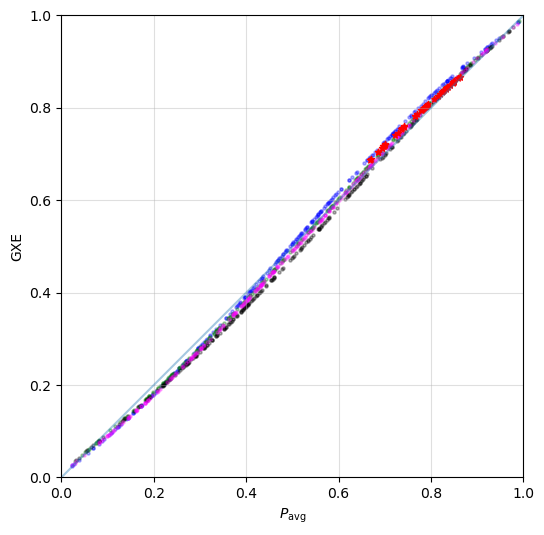

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import mean_absolute_error as MAE

# ===========================
fig, ax = plt.subplots(figsize=(6,6))

# crudely implementing 4 random plots
colors = ['b','g','k','magenta'];

for i in range(4):
    df = GXE_simulate()
    ax.scatter(df.P_avg.values, (1/100)*df.GXE.values, c=colors[i], s=5, alpha=0.3)
    print("mse =", np.round(MSE(df.P_avg.values, (1/100)*df.GXE.values),6))

# df = GXE_simulate()
# ax.scatter(df.P_avg.values, (1/100)*df.GXE.values, c='g', s=5, alpha=0.3)
# print("mse =", np.round(MSE(df.P_avg.values, (1/100)*df.GXE.values),6))

# df = GXE_simulate()
# ax.scatter(df.P_avg.values, (1/100)*df.GXE.values, c='k', s=5, alpha=0.3)
# print("mse =", np.round(MSE(df.P_avg.values, (1/100)*df.GXE.values),6))

# df = GXE_simulate()
# ax.scatter(df.P_avg.values, (1/100)*df.GXE.values, c='magenta', s=5, alpha=0.3)
# print("mse =", np.round(MSE(df.P_avg.values, (1/100)*df.GXE.values),6))
# ===========================
# X-Act's
ax.scatter((1/100)*df_xact.TrueR.values, (1/100)*df_xact.GXE.values, c='r', s=20, marker='*')
print("xact MSE =", np.round(MSE((1/100)*df_xact.TrueR.values, (1/100)*df_xact.GXE.values),6))

ax.set_xlabel(r"$P_{\mathrm{avg}}$")
ax.set_ylabel(r"GXE")
ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_aspect('equal')
ax.grid(True, alpha=0.4)

ax.axline((0,0),(1,1), alpha=0.4)

plt.show()

In [286]:
# X-Act's data
xact_MSE = MSE((1/100)*df_test.TrueR.values, (1/100)*df_test.GXE.values)
xact_MAE = MAE((1/100)*df_test.TrueR.values, (1/100)*df_test.GXE.values)
print("X-Act's \tMSE =", np.round(xact_MSE,6), "\tMAE =", np.round(xact_MAE,6))
print()

# my trials
n_trials = 10
avg_MSE = 0; avg_MAE = 0;
for i in range(n_trials):
    trial_MSE = 0; trial_MAE = 0;
    df = GXE_simulate()
    
    trial_MSE = MSE(df.P_avg.values, (1/100)*df.GXE.values)
    avg_MSE += trial_MSE
    
    trial_MAE = MAE(df.P_avg.values, (1/100)*df.GXE.values)
    avg_MAE += trial_MAE
    print(f"Trial {i} \tMSE =", np.round(trial_MSE,5), f"\tMAE =", np.round(trial_MAE,6))

print(f"Trials' avg \tMSE =", np.round(avg_MSE/n_trials,6), "\tMAE =", np.round(avg_MAE/n_trials,6))

X-Act's 	MSE = 0.00022 	MAE = 0.01401

Trial 0 	MSE = 0.00052 	MAE = 0.019383
Trial 1 	MSE = 0.00044 	MAE = 0.016704
Trial 2 	MSE = 3e-05 	MAE = 0.004688
Trial 3 	MSE = 0.00069 	MAE = 0.023104
Trial 4 	MSE = 9e-05 	MAE = 0.008267
Trial 5 	MSE = 0.00035 	MAE = 0.016866
Trial 6 	MSE = 0.0012 	MAE = 0.031859
Trial 7 	MSE = 0.00033 	MAE = 0.015631
Trial 8 	MSE = 0.00042 	MAE = 0.017682
Trial 9 	MSE = 0.00018 	MAE = 0.012311
Trials' avg 	MSE = 0.000425 	MAE = 0.01665
